In [10]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pi0-analysis" in root.split("/"):
        pypath = root.split("pi0-analysis")[0] + "/pi0-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

import awkward as ak
import numpy as np

from iminuit import minimize
from python.analysis import cross_section, Tags, Plots, Master, vector, SelectionTools, BeamParticleSelection
from apps.cex_analysis_input import BeamPionSelection
from apps import cex_selection_studies, cex_analysis_input
cross_section.PlotStyler.SetPlotStyle(extend_colors = True, dpi = 100)

/home/suw//pi0-analysis/analysis
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/suw//pi0-analysis/analysis
env: PYTHONPATH=/home/suw//pi0-analysis/analysis


In [2]:
args_pion = cross_section.ApplicationArguments.ResolveConfig(cross_section.LoadConfiguration("/home/suw/pi0-analysis/analysis/work/cex_analysis_2GeV_config.json"))
args_pion.ntuple_files["mc"][0]

{'file': '/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4a_MC_2GeV_sce_datadriven_ntuple_v09_81_00d01_set0.root',
 'type': 'PDSPAnalyser',
 'pmom': 1}

/home/suw//pi0-analysis/analysis/python/analysis/Plots.py:897: UserWarning: pdf has not been opened.
  warnings.warn("pdf has not been opened.")


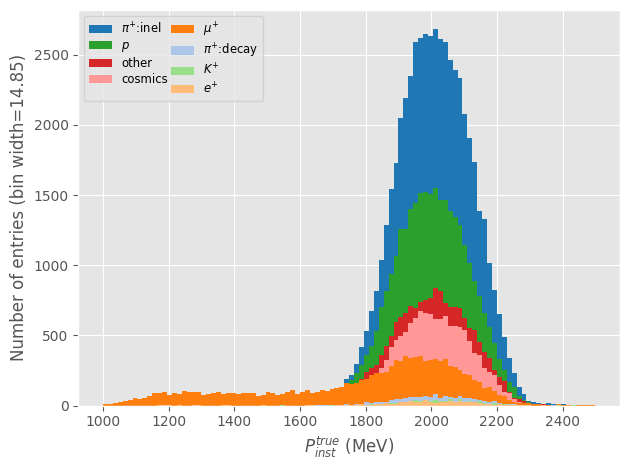

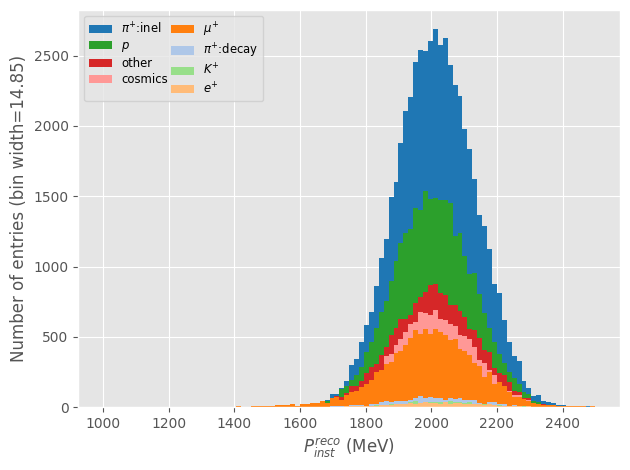

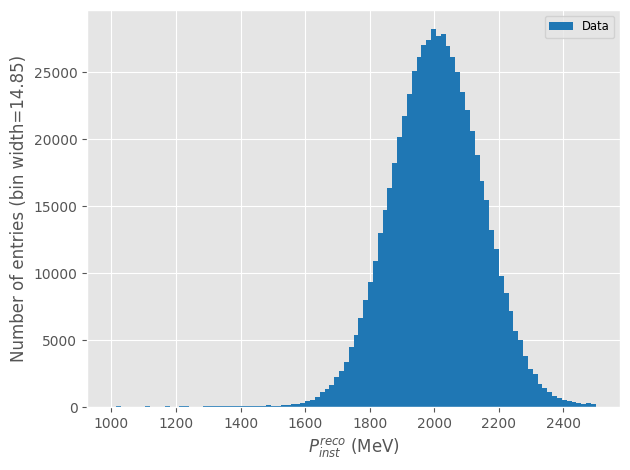

In [3]:
file_names = {k : v[0]["file"] for k, v in args_pion.ntuple_files.items()}
samples_pion = {k : Master.Data(v, nTuple_type= args_pion.ntuple_files[k][0]["type"], target_momentum = args_pion.ntuple_files[k][0]["pmom"]) for k, v in file_names.items()}
with Plots.PlotBook("2GeV_beam_momenta_profile.pdf", False) as book:
    Plots.PlotTagged(vector.magnitude(samples_pion["mc"].trueParticles.momentum[:, 0]), Tags.GenerateTrueBeamParticleTags(samples_pion["mc"]), y_scale = "linear", stacked = False, reverse_sort = True, x_range = args_pion.P_inst_range, x_label = "$P_{inst}^{true}$ (MeV)", loc = "upper left")
    book.Save()
    Plots.PlotTagged(samples_pion["mc"].recoParticles.beam_inst_P, Tags.GenerateTrueBeamParticleTags(samples_pion["mc"]), y_scale = "linear", stacked = False, reverse_sort = True, x_range = args_pion.P_inst_range, x_label = "$P_{inst}^{reco}$ (MeV)", loc = "upper left")
    book.Save()
    Plots.PlotHist(samples_pion["data"].recoParticles.beam_inst_P, range = args_pion.P_inst_range, xlabel = "$P_{inst}^{reco}$ (MeV)", label = "Data")
    book.Save()

In [7]:
args_pion.selection_masks["mc"]["fiducial"]

{np.str_('/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4a_MC_2GeV_reco1_sce_datadriven_v1_ntuple_v09_41_00_03.root'): {'TrueFiducialCut': <Array [False, True, False, True, ..., False, False, True] type='141548 * bool'>,
  'APA3Cut': <Array [False, False, False, True, ..., True, False, True] type='141548 * bool'>},
 np.str_('/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4a_MC_2GeV_sce_datadriven_ntuple_v09_81_00d01_set0.root'): {'TrueFiducialCut': <Array [True, False, True, True, ..., True, True, False] type='131266 * bool'>,
  'APA3Cut': <Array [True, True, True, True, ..., False, True, False] type='131266 * bool'>},
 np.str_('/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4a_MC_2GeV_sce_datadriven_ntuple_v09_81_00d01_set1.root'): {'TrueFiducialCut': <Array [True, True, True, False, ..., True, True, True] type='130635 * bool'>,
  'APA3Cut': <Array [True, True, False, False, ..., False, True, True] type='130635 * bool'>},
 np.str_('/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4a_MC

In [13]:
args_pion.selection_masks["data"]

{'beam': {np.str_('/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4_data_2GeV_reco2_ntuple_v09_42_03_01.root'): {'TrueFiducialCut': <Array [True, True, True, True, ..., True, True, True] type='263960 * bool'>,
   'PiBeamSelection': <Array [False, False, True, ..., False, False, False] type='263960 * bool'>,
   'PandoraTagCut': <Array [True, True, True, True, ..., True, True, True] type='263960 * bool'>,
   'CaloSizeCut': <Array [True, True, True, True, ..., True, True, True] type='263960 * bool'>,
   'HasFinalStatePFOsCut': <Array [False, True, False, True, ..., True, True, True] type='263960 * bool'>,
   'APA3Cut': <Array [True, True, True, True, ..., True, True, True] type='263960 * bool'>,
   'DxyCut': <Array [False, True, False, ..., False, True, False] type='263960 * ?bool'>,
   'CosThetaCut': <Array [False, True, True, True, ..., True, True, False] type='263960 * ?bool'>,
   'MichelScoreCut': <Array [True, True, True, True, ..., True, True, True] type='263960 * bool'>,
   'Median

In [16]:
data_selected = cex_analysis_input.BeamPionSelection(samples_pion["data"], args_pion, False)
mc_selected = cex_analysis_input.BeamPionSelection(samples_pion["mc"], args_pion, True)

f=<Array [False, False, False, ..., False, True, False] type='1349399 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='263960 * ?bool'>
f=<Array [[True, True, ..., False, False], ...] type='59626 * option[var * bool]'>


'BeamPionSelection' executed in 0.1163s

f=<Array [True, False, True, True, ..., False, True, False] type='131266 * bool'>
f=<Array [False, False, True, True, ..., False, True, False] type='52654 * ?bool'>
f=<Array [[True, True, ..., True, True], ...] type='20516 * option[var * bool]'>


'BeamPionSelection' executed in 0.0406s

In [ ]:
reco_regions, true_regions = cex_analysis_input.RegionSelection(mc_selected, args_pion, True)

In [20]:
args_pion.selection_masks["data"]["pi"]

{np.str_('/data/dune/common/PDSPAnalyzer_Ntuples/PDSPProd4_data_2GeV_reco2_ntuple_v09_42_03_01.root'): {'Chi2ProtonSelection': <Array [[False, False, ..., True, True], ...] type='59626 * option[var * bool]'>,
  'TrackLengthSelection': <Array [[True, False, ..., False, False], ...] type='59626 * option[var * b...'>,
  'TrackScoreCut': <Array [[False, True, ..., False, False], ...] type='59626 * option[var * b...'>,
  'NHitsCut': <Array [[True, True, ..., True, True], ...] type='59626 * option[var * bool]'>,
  'PiPlusSelection': <Array [[False, False, True, ..., False, False], ...] type='59626 * var * bool'>}}

In [24]:
n_pi = SelectionTools.GetPFOCounts(args_pion.selection_masks["mc"]["pi"][file_names["mc"]])